# Phan tich Diabetes Health Indicators

Notebook nay xay dung quy trinh phan loai benh tieu duong tu cac chi so suc khoe. Du lieu co so dac trung vua phai nhung mat can bang lop, nen trong tam la so sanh baseline, SMOTE va SMOTE+ENN.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_diabetes_data
from src.feature_analysis import eda_summary
from src.feature_selection import filter_select_kbest, choose_filter_result, wrapper_rfecv
from src.resampling import get_resamplers, make_resampled_versions
from src.pipeline import make_split, make_cv
from src.preprocessing import preprocess_train_test
from src.classification import train_models_for_versions
from src.evaluation import results_to_dataframe
from src.visualization import (
    plot_class_distribution, plot_correlation_heatmap, plot_tsne, plot_umap,
    plot_roc_curves, plot_model_comparison, plot_feature_importance, plot_learning_curves
)

RANDOM_STATE = 42
DIABETES_PATH = PROJECT_ROOT / 'diabetes'

## 1. EDA

Buoc EDA giup hieu kich thuoc du lieu, phan bo lop co/khong co tieu duong, gia tri thieu, phan bo dac trung va muc mat can bang lop.

In [2]:
X, y = load_diabetes_data(DIABETES_PATH)
summary = eda_summary(X, y)
print('Shape:', X.shape)
print('Imbalance ratio:', summary['imbalance_ratio'])
display(summary['class_distribution'])
display(summary['missing_values'].query('missing_count > 0'))
display(summary['feature_distributions'])

Shape: (253680, 21)
Imbalance ratio: 6.177049736886777


,count,percent
Diabetes_binary,,
0,218334,86.066698
1,35346,13.933302


,missing_count,missing_percent


,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


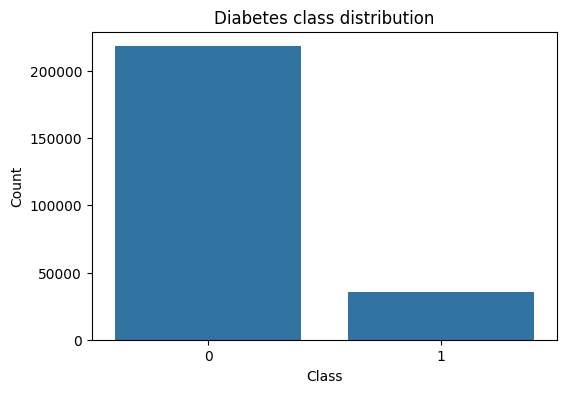

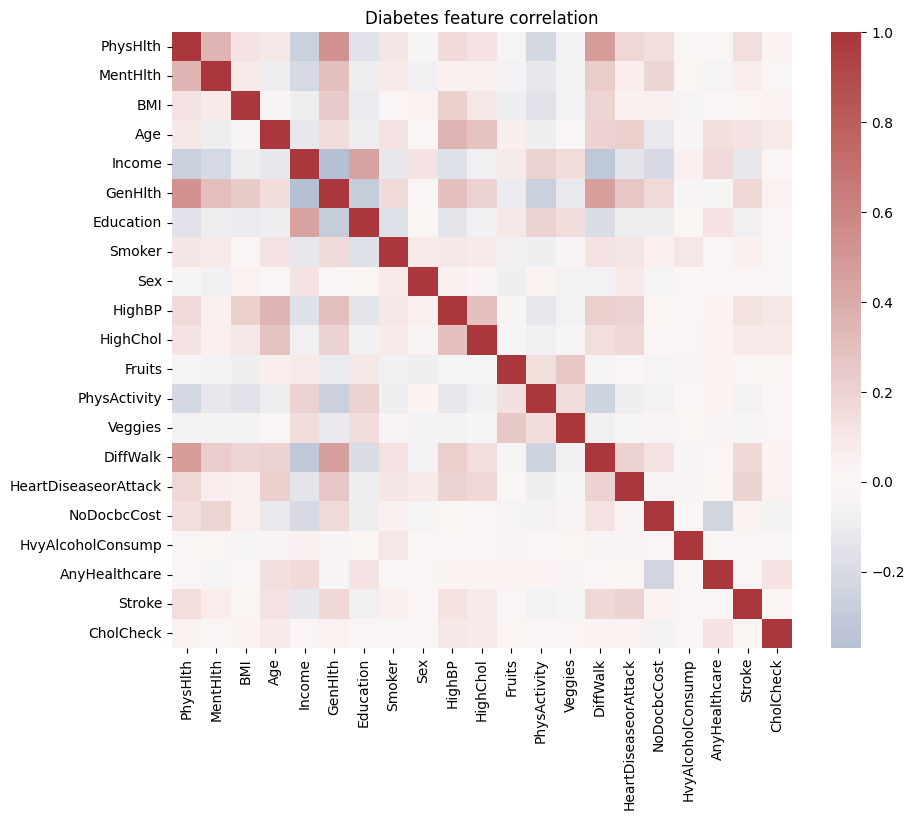

In [3]:
plot_class_distribution(y, 'Diabetes class distribution');
plot_correlation_heatmap(summary['correlation_matrix'], 'Diabetes feature correlation');

## 2. Preprocessing

Du lieu duoc chia train/test 80/20 bang stratified sampling. Median imputation, StandardScaler va LabelEncoder chi fit tren train set de test set van la du lieu chua tung thay.

In [4]:
X_train, X_test, y_train, y_test = make_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_p, X_test_p, y_train_p, y_test_p, processor = preprocess_train_test(X_train, X_test, y_train, y_test)
cv = make_cv(k=5, random_state=RANDOM_STATE)
print(X_train_p.shape, X_test_p.shape)
print(dict(zip(processor.label_encoder.classes_, range(len(processor.label_encoder.classes_)))))

(202944, 21) (50736, 21)
{'0': 0, '1': 1}


## 3. Visualization

t-SNE va UMAP giup quan sat du lieu trong khong gian 2 chieu. Neu cac diem cua hai lop dan xen phuc tap, cac mo hinh phi tuyen co the co loi the.

C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^

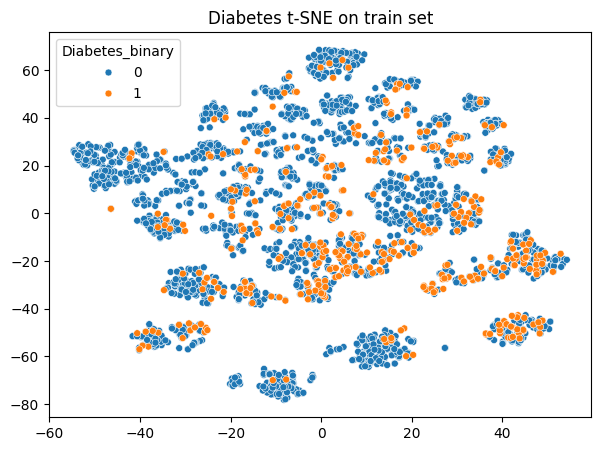

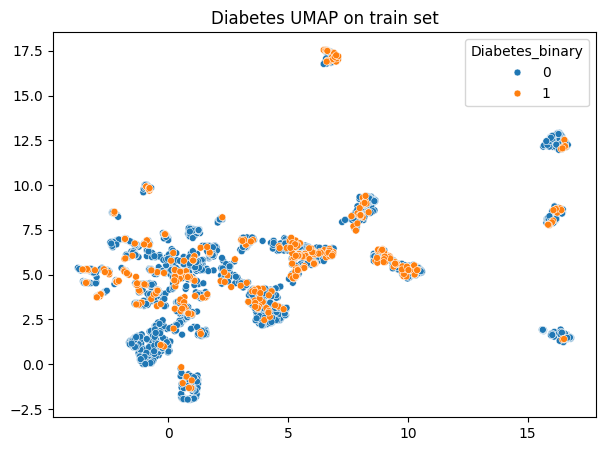

In [5]:
plot_tsne(X_train_p, y_train_p, title='Diabetes t-SNE on train set', max_samples=3000);
plot_umap(X_train_p, y_train_p, title='Diabetes UMAP on train set', max_samples=3000);

## 4. Feature Selection

Feature selection van duoc chay de giu quy trinh chung. Tuy nhien, day khong phai trong tam cua Diabetes vi du lieu chi co khoang 20 dac trung; loi ich lon hon thuong den tu xu ly mat can bang lop.

In [6]:
filter_results = filter_select_kbest(X_train_p, y_train_p, X_test_p, k_values=(5, 10, 15, 20))
filter_result = choose_filter_result(filter_results, preferred_k=10)
wrapper_result = wrapper_rfecv(
    X_train_p, y_train_p, X_test_p,
    cv=cv, min_features_to_select=5, step=1, random_state=RANDOM_STATE
)
print('Filter selected:', len(filter_result.selected_features))
print('Wrapper selected:', len(wrapper_result.selected_features))
display(wrapper_result.ranking)

Filter selected: 10
Wrapper selected: 20


,feature,rank,selected
18,Age,1,True
11,AnyHealthcare,1,True
3,BMI,1,True
16,DiffWalk,1,True
19,Education,1,True
8,Fruits,1,True
13,GenHlth,1,True
6,HeartDiseaseorAttack,1,True
0,HighBP,1,True
1,HighChol,1,True


## 5. Resampling

Day la trong tam cua Diabetes. Baseline giu nguyen train set, SMOTE tao mau thieu so tong hop, con SMOTE+ENN vua tao mau vua lam sach cac diem nhieu.

In [7]:
resampled = make_resampled_versions(X_train_p, y_train_p, random_state=RANDOM_STATE)
samplers = get_resamplers(random_state=RANDOM_STATE)
data_versions = {
    name: {'X_train': X_train_p, 'y_train': y_train_p, 'X_test': X_test_p, 'sampler': sampler}
    for name, sampler in samplers.items()
}
data_versions['filter-selected'] = {
    'X_train': filter_result.X_train, 'y_train': y_train_p, 'X_test': filter_result.X_test
}
data_versions['wrapper-selected'] = {
    'X_train': wrapper_result.X_train, 'y_train': y_train_p, 'X_test': wrapper_result.X_test
}
for name, result in resampled.items():
    print('Preview after fitting sampler on train only:', name, result.X.shape, result.y.value_counts().to_dict())
print('During GridSearchCV, samplers are fitted inside each CV training fold.')
X_test_lookup = {name: version['X_test'] for name, version in data_versions.items()}

Preview after fitting sampler on train only: baseline (202944, 21) {0: 174667, 1: 28277}
Preview after fitting sampler on train only: SMOTE (349334, 21) {0: 174667, 1: 174667}
Preview after fitting sampler on train only: SMOTE+ENN (271124, 21) {1: 154911, 0: 116213}
During GridSearchCV, samplers are fitted inside each CV training fold.


## 6. Classification

Moi phien ban du lieu duoc huan luyen voi 5 mo hinh: Logistic Regression, SVM RBF, Random Forest, XGBoost va MLP. Tat ca dung GridSearchCV voi Stratified K-Fold 5 folds tren train set.

In [ ]:
results = train_models_for_versions(
    data_versions, X_test_p, y_test_p,
    cv=cv, random_state=RANDOM_STATE, scoring='f1', experiment_prefix='Diabetes | '
)
results_df = results_to_dataframe(results)
display(results_df)

## 7. Evaluation

Voi Diabetes, F1-score va ROC-AUC la chi so chinh vi du lieu mat can bang. Accuracy van duoc ghi lai nhung chi de tham khao.

In [ ]:
plot_model_comparison(results_df, metric='test_f1', title='Diabetes model comparison by F1');
plot_model_comparison(results_df, metric='test_roc_auc', title='Diabetes model comparison by ROC-AUC');
plot_roc_curves(results, X_test_lookup=X_test_lookup, y_test=y_test_p, title='Diabetes ROC curves');
best = results_df.iloc[0]
best_result = next(r for r in results if r['experiment'] == best['experiment'])
print(best[['experiment', 'test_accuracy', 'test_f1', 'test_roc_auc', 'best_params']])
print(best_result['metrics']['confusion_matrix'])

## 8. Feature Importance va Learning Curves

Feature importance giup giai thich cac chi so suc khoe lien quan manh den du doan. Learning curves so sanh LR, RF va XGBoost; neu LR bi plateau thap hon mo hinh cay, dieu nay ung ho nhan dinh du lieu co quan he phi tuyen.

In [ ]:
best_version = best_result['data_version']
best_X_test = X_test_lookup[best_version]
plot_feature_importance(
    best_result['best_estimator'], best_X_test, y_test_p,
    top_n=20, title=f"Diabetes feature importance: {best['experiment']}"
);
plot_learning_curves(
    data_versions[best_version]['X_train'], data_versions[best_version]['y_train'],
    cv=cv, random_state=RANDOM_STATE
);